In [1]:
# Install the finance library
!pip install yfinance prophet

import yfinance as yf
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [2]:
# Fetching Bitcoin data for the last 3 years
# Ticker: BTC-USD
data = yf.download('BTC-USD', period='3y', interval='1d')

# Reset index to get 'Date' as a column
df = data.reset_index()

# Prophet requires columns to be named 'ds' (datestamp) and 'y' (value)
df = df[['Date', 'Close']]
df.columns = ['ds', 'y']

# Remove timezone information from the 'ds' column to avoid errors
df['ds'] = df['ds'].dt.tz_localize(None)

print("Data successfully loaded. Preview:")
print(df.tail())

/tmp/ipykernel_3222/3590715585.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', period='3y', interval='1d')
[*********************100%***********************]  1 of 1 completed

Data successfully loaded. Preview:
             ds             y
1092 2026-04-16  75152.132812
1093 2026-04-17  77126.875000
1094 2026-04-18  75726.210938
1095 2026-04-19  73856.351562
1096 2026-04-20  75437.750000


In [3]:
# Initialize the Prophet model
model = Prophet(daily_seasonality=True)

# Fit the model with our historical Bitcoin data
model.fit(df)

print("Model training complete.")

Model training complete.


In [4]:
# Create a dataframe for the next 30 days
future = model.make_future_dataframe(periods=30)

# Use the model to predict the future prices
forecast = model.predict(future)

# Display the top 5 predicted values
print("Forecasted Prices for the next few days:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Forecasted Prices for the next few days:
             ds          yhat    yhat_lower    yhat_upper
1122 2026-05-16  58492.350139  52891.422528  64880.075736
1123 2026-05-17  58337.513161  51849.300199  64191.495815
1124 2026-05-18  58384.365992  52093.340540  64842.135311
1125 2026-05-19  57989.101801  51612.088116  64679.632559
1126 2026-05-20  58126.798058  51858.893973  63999.992919


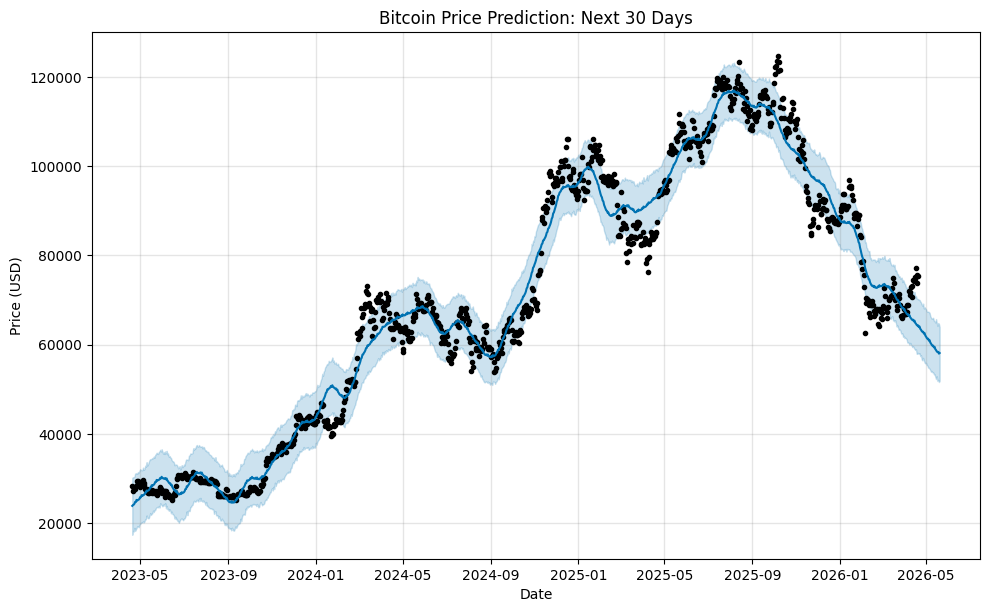

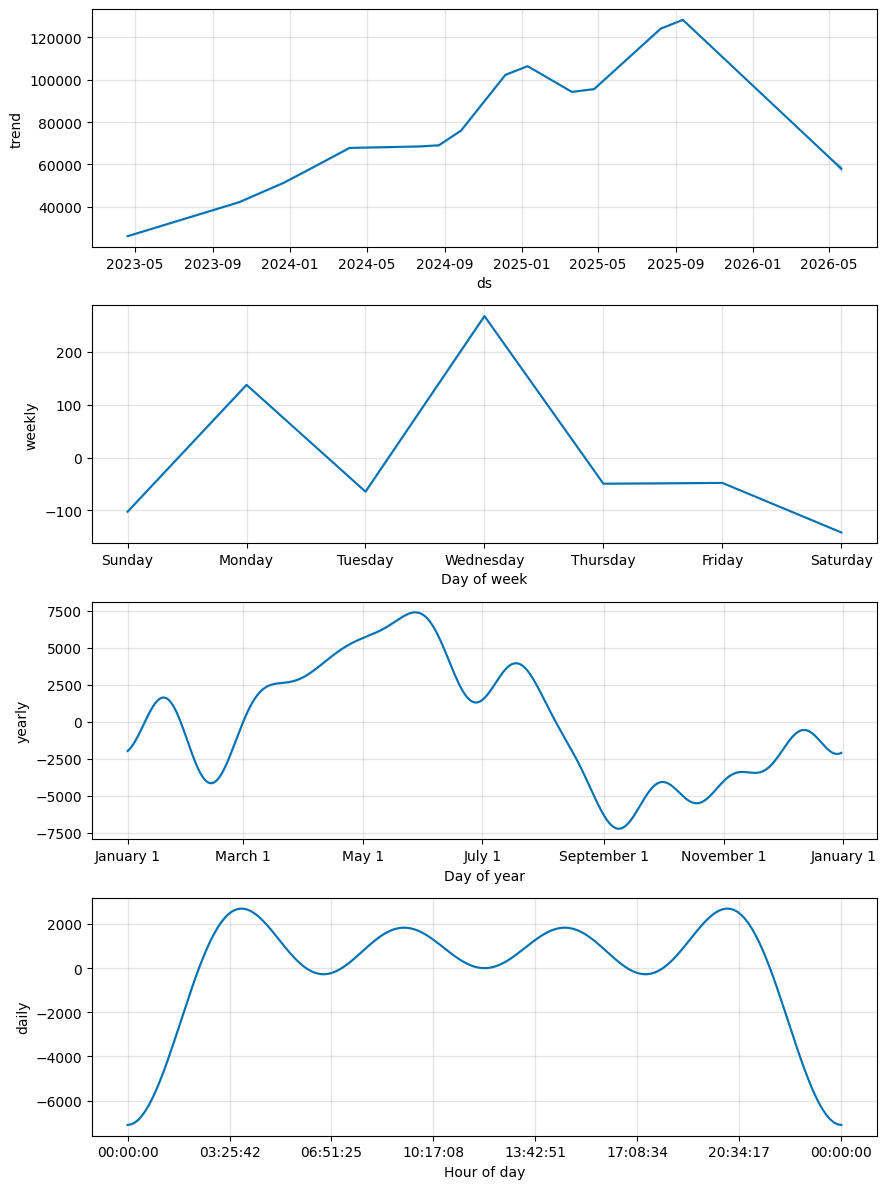

In [5]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Bitcoin Price Prediction: Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Plot the components (Trend, Weekly, and Yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [6]:
import yfinance as yf
import time
from IPython.display import clear_output

# The crypto ticker you want to track
symbol = "BTC-USD"

print(f"Starting Live Ticker for {symbol}...")
print("Press 'Stop' (interrupt execution) to end the loop.\n")

try:
    while True:
        # Fetch the latest data (1 minute interval)
        ticker_data = yf.Ticker(symbol)
        current_price = ticker_data.history(period='1d', interval='1m')['Close'].iloc[-1]

        # Clear the previous output so it stays on one line
        clear_output(wait=True)

        # Print the price with a timestamp
        timestamp = time.strftime("%H:%M:%S")
        print(f"-------------------------------")
        print(f" LIVE {symbol} PRICE TICKER ")
        print(f"-------------------------------")
        print(f" TIME  : {timestamp}")
        print(f" PRICE : ${current_price:,.2f}")
        print(f"-------------------------------")

        # Wait for 10 seconds before refreshing
        time.sleep(10)

except KeyboardInterrupt:
    print("\nTicker Stopped.")

-------------------------------
 LIVE BTC-USD PRICE TICKER 
-------------------------------
 TIME  : 15:26:17
 PRICE : $75,592.00
-------------------------------

Ticker Stopped.
